<a href="https://colab.research.google.com/github/khoirulanam61417-ux/UTS_PCD_23424017_KHOIRUL-ANAM/blob/main/Soal_No_2_Konvolusi_(LPF%2C_HPF%2C_BPF).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Upload gambar untuk pengujian filter (LPF, HPF, BPF):


Saving gojo-hollow-purple.jpg to gojo-hollow-purple.jpg
Nilai piksel rata-rata Original: 89.07
Nilai piksel rata-rata LPF (Blur): 89.07
Nilai piksel rata-rata HPF (Edge Detection): 5.11
Nilai piksel rata-rata BPF (Sharpening): 89.21


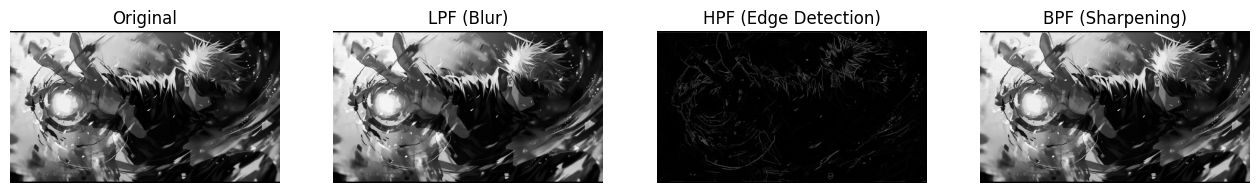

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

# Langkah Upload File
print("Upload gambar untuk pengujian filter (LPF, HPF, BPF):")
uploaded = files.upload()
file_name = list(uploaded.keys())[0]

img = cv2.imdecode(np.frombuffer(uploaded[file_name], np.uint8), cv2.IMREAD_GRAYSCALE)

# 1. Definisi Kernel sesuai tabel soal [cite: 36]
lpf_kernel = np.ones((3, 3), np.float32) / 9
hpf_kernel = np.array([[-1, -1, -1], [-1, 8, -1], [-1, -1, -1]])
bpf_kernel = np.array([[0, -1, 0], [-1, 5, -1], [0, -1, 0]])

# 2. Terapkan Konvolusi [cite: 38]
img_lpf = cv2.filter2D(img, -1, lpf_kernel)
img_hpf = cv2.filter2D(img, -1, hpf_kernel)
img_bpf = cv2.filter2D(img, -1, bpf_kernel)

# 3. Tampilkan dalam satu figure (4 gambar) [cite: 39]
titles = ['Original', 'LPF (Blur)', 'HPF (Edge Detection)', 'BPF (Sharpening)']
images = [img, img_lpf, img_hpf, img_bpf]

plt.figure(figsize=(16, 4))
for i in range(4):
    plt.subplot(1, 4, i+1)
    plt.imshow(images[i], cmap='gray')
    plt.title(titles[i])
    plt.axis('off')

    # Menampilkan nilai piksel rata-rata untuk analisa [cite: 41]
    avg_val = np.mean(images[i])
    print(f"Nilai piksel rata-rata {titles[i]}: {avg_val:.2f}")

plt.show()